In [2]:
import zipfile 

zip_path = "../data/ml-1m.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print(zip_ref.namelist())

['ml-1m/', 'ml-1m/movies.dat', 'ml-1m/ratings.dat', 'ml-1m/README', 'ml-1m/users.dat']


In [3]:
zip_path = "../data/ml-1m.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    with zip_ref.open("ml-1m/movies.dat") as file:
        for _ in range(5):
            print(file.readline().decode('utf-8'))

1::Toy Story (1995)::Animation|Children's|Comedy

2::Jumanji (1995)::Adventure|Children's|Fantasy

3::Grumpier Old Men (1995)::Comedy|Romance

4::Waiting to Exhale (1995)::Comedy|Drama

5::Father of the Bride Part II (1995)::Comedy



In [ ]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("../data/")
    print("Complete extraction!")

In [7]:
movies = pd.read_csv(
    "../data/ml-1m/movies.dat",
    sep="::",
    engine="python",
    names=["movie_id", "title", "genres"],
    encoding="latin-1"
)

movies.head()


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [9]:
users = pd.read_csv(
    "../data/ml-1m/users.dat",
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip_code"]
)

users.head()


,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [5]:
import pandas as pd 

ratings = pd.read_csv(
    "../data/ml-1m/ratings.dat",
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [10]:
# Matrix sparsity
num_users = ratings["user_id"].nunique()
num_items = ratings["movie_id"].nunique()
num_ratings = len(ratings)

sparsity = 1 - num_ratings / (num_users * num_items)

print("Number of users: ", num_users)
print("Number of items: ", num_items)
print("Total number of ratings: ", num_ratings)
print("Sparsity: ", sparsity)

Number of users:  6040
Number of items:  3706
Total number of ratings:  1000209
Sparsity:  0.9553163743776871


Matplotlib is building the font cache; this may take a moment.


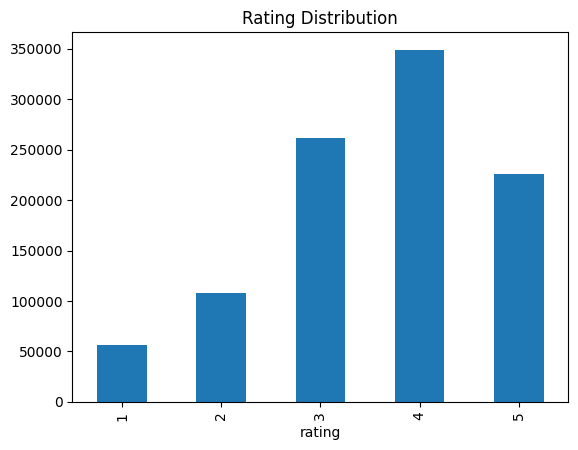

In [11]:
import matplotlib.pyplot as plt 

ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.show()

In [33]:
# User activity 
rating_per_users = ratings.groupby("user_id").size()
print(rating_per_users[:5])
rating_per_users.describe()

user_id
1     53
2    129
3     51
4     21
5    198
dtype: int64


count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64

In [20]:
top_10_users = rating_per_users.sort_values("rating_count", ascending=False).head(10)
print(top_10_users)

      user_id  rating_count
4168     4169          2314
1679     1680          1850
4276     4277          1743
1940     1941          1595
1180     1181          1521
888       889          1518
3617     3618          1344
2062     2063          1323
1149     1150          1302
1014     1015          1286


In [22]:
# Item popularity 
ratings_for_items = ratings.groupby("movie_id").size()
ratings_for_items.describe()

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
dtype: float64

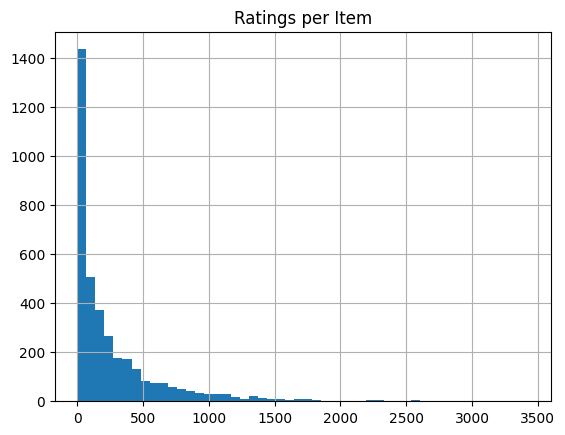

In [28]:
ratings_for_items.hist(bins=50)
plt.title("Ratings per Item")
plt.show()

In [42]:
# Cold-start problem 
cold_users = (rating_per_users <= 100).sum()
cold_items = (ratings_for_items <= 5).sum()
print("Users with <= 100 ratings: ", cold_users)
print("Items with <= 5 ratings: ", cold_items)
print("Percentage of users with <= 100 ratings: ", cold_users * 100 / len(rating_per_users))
print("Percentage of items with <= 5 ratings: ", cold_items * 100 / len(ratings_for_items))

Users with <= 100 ratings:  3131
Items with <= 5 ratings:  329
Percentage of users with <= 100 ratings:  51.83774834437086
Percentage of items with <= 5 ratings:  8.877495952509443
